# DIRT-Based Estimation of Model Evidence: Rosenbrock Example

In [10]:
from typing import Callable

from matplotlib import pyplot as plt
import torch 
from torch import Tensor

import deep_tensor as dt

torch.manual_seed(0);

We start by defining the target density (setup reproduced from [here](https://arxiv.org/pdf/2405.05969), Sec. 4.2.1).

In [11]:
# Define unnormalised target function

dim = 2

def neglogpost(xs: Tensor) -> Tensor:
    # Note: not the log-prior density but aligns with 
    # https://github.com/astro-informatics/harmonic/blob/main/examples/rosenbrock.py
    neglogpri = -1.0/400.0
    neglogliks = torch.zeros_like(xs[:, 0])
    for i in range(dim-1):
        neglogliks += (100*(xs[:, i+1] - xs[:, i]**2)**2 + (1.0 - xs[:, i])**2)
    return neglogpri + neglogliks

def post(xs: Tensor) -> Tensor:
    return torch.exp(-neglogpost(xs))

Next, we construct a DIRT approximation to the target function.

In [12]:
target_func = dt.TargetFunc(neglogpost)

# Define extent of prior
bounds = torch.tensor([[-10.0, 10.0], [-5.0, 15.0]])
preconditioner = dt.UniformMapping(bounds)

# Define approximation basis to use at each layer
basis = dt.Fourier(order=15)
bases = dt.ApproxBases(basis, dim)

# Define properties of FTT approximation to use at each layer
tt_options = dt.TTOptions(tt_method="fixed_rank", init_rank=6)
tt = dt.TT(tt_options)
ftt = dt.FTT(bases, tt)

# Define tempering parameters (which determine the function approximated at each layer)
betas = 10 ** torch.linspace(-4.0, 0.0, 5)
bridge = dt.Tempering(betas=betas)

In [13]:
# Construct DIRT approximation. Note: with this set of hyperparameters, 
# <2000 samples are used to construct the DIRT approximation. The rest 
# are used for diagnostic purposes (this can be turned off).
dirt = dt.DIRT(target_func, preconditioner, ftt, bridge)

[DIRT] Iter:  1 | Cum. Fevals: 0.00e+00 | Cum. Time: 1.28e-02 s | Beta: 0.0001 | DHell: 0.0000 | ESS: 0.3670
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       1384 |        6 |       1.00e+00 |        1.00e+00 | 3.77e-02
[ALS]  ALS complete.
[DIRT] Iter:  2 | Cum. Fevals: 2.38e+03 | Cum. Time: 8.70e-02 s | Beta: 0.0010 | DHell: 0.0149 | ESS: 0.5176
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       1384 |        6 |       8.59e-01 |        8.13e-01 | 4.98e-02
[ALS]  ALS complete.
[DIRT] Iter:  3 | Cum. Fevals: 4.77e+03 | Cum. Time: 2.24e-01 s | Beta: 0.0100 | DHell: 0.0309 | ESS: 0.4230
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |       1384 |        6 |       5.51e-01 |        2.97e-01 | 1.97e-03
[ALS]  ALS complete.
[DIRT] Iter:  4 | Cum. Fevals: 7.15e+03 | Cum. Time: 2.90e-01 s | Beta: 0.1000 | DHell: 0.0301 | ESS: 0.3610
[ALS]  It

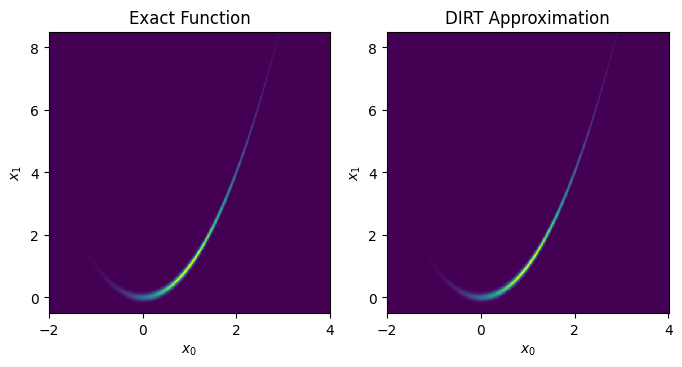

In [14]:
PLOT_DIRT_APPROX = True 

if PLOT_DIRT_APPROX:

    n = 500
    x0s = torch.linspace(-2.0, 4.0, n)
    x1s = torch.linspace(-0.5, 8.5, n)
    xs_grid = torch.tensor([[x0, x1] for x1 in x1s for x0 in x0s])
    posts_exact = torch.exp(-neglogpost(xs_grid)).reshape(n, n)
    posts_dirt = dirt.eval_pdf(xs_grid).reshape(n, n)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].pcolormesh(x0s, x1s, posts_exact)
    axes[1].pcolormesh(x0s, x1s, posts_dirt)

    axes[0].set_title("Exact Function")
    axes[1].set_title("DIRT Approximation")

    for ax in axes:
        ax.set_box_aspect(1)
        ax.set_xlabel(r"$x_{0}$")
        ax.set_ylabel(r"$x_{1}$")

Finally, we can estimate the evidence using importance sampling.

In [15]:
def estimate_evidence(
    neglogpost: Callable[[Tensor], Tensor], 
    dirt: dt.DIRT, 
    num_samples: int
) -> Tensor:
    """Computes an importance sampling estimate of the evidence."""
    
    # Generate a set of samples from DIRT approximation
    rs = dirt.reference.random(n=num_samples, d=dim)
    xs, neglogposts_dirt = dirt.eval_irt(rs)
    
    # Evaluate the exact (unnormalised) posterior at each sample
    neglogposts_exact = neglogpost(xs)
    
    # Estimate evidence using importance sampling
    res = dt.run_importance_sampling(neglogposts_dirt, neglogposts_exact)
    evidence_estimate = res.log_norm.exp()
    
    return evidence_estimate

In [16]:
# Generate a set of DIRT evidence estimates
num_runs = 100
evidence_estimates = torch.zeros((num_runs,))
for i in range(num_runs):
    evidence_estimates[i] = estimate_evidence(neglogpost, dirt, num_samples=1000)

In [17]:
# Estimate evidence using quadrature

n = 1000
x0s = torch.linspace(-10.0, 10.0, n)
x1s = torch.linspace(-5.0, 15.0, n)
dx0 = x0s[1] - x0s[0]
dx1 = x1s[1] - x1s[0]
xs_grid = torch.tensor([[x0, x1] for x1 in x1s for x0 in x0s])

post_grid = post(xs_grid)

evidence_numerical = torch.sum(post_grid) * dx0 * dx1
inverse_evidence_numerical = 1.0 / evidence_numerical

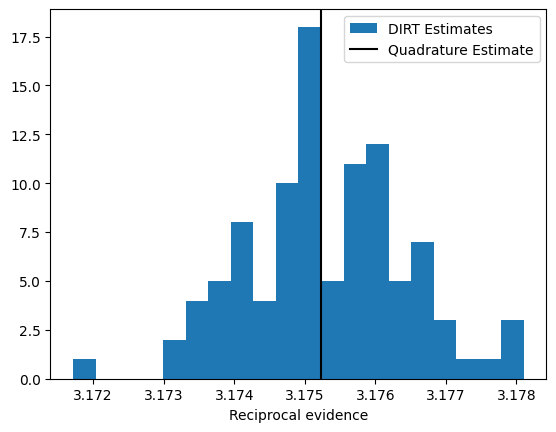

In [18]:
# Plot the obtained estimates of the evidence 
# (c.f. Fig. 3 of https://arxiv.org/pdf/2405.05969)
plt.hist(1.0 / evidence_estimates, bins=20, label="DIRT Estimates")
plt.axvline(inverse_evidence_numerical, label="Quadrature Estimate", c="k")  # type: ignore
plt.xlabel("Reciprocal evidence")
plt.legend()